In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Pull 2 years of HSBC data
hsbc = yf.download("HSBA.L", period="2y", auto_adjust=True)

df = pd.DataFrame()
df['price'] = hsbc['Close'].values.flatten()
df['volume'] = hsbc['Volume'].values.flatten()
df.index = hsbc.index

print("Shape:", df.shape)
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Shape: (507, 2)
                  price    volume
Date                             
2026-03-16  1195.800049  16539898
2026-03-17  1207.199951  18852466
2026-03-18  1209.199951  23027117
2026-03-19  1171.599976  37288494
2026-03-20  1144.199951  84775948


In [3]:
# Daily return
df['return'] = df['price'].pct_change() * 100

# Previous returns
df['prev_return_1'] = df['return'].shift(1)
df['prev_return_2'] = df['return'].shift(2)
df['prev_return_3'] = df['return'].shift(3)

# Moving averages
df['ma_5'] = df['price'].rolling(window=5).mean()
df['ma_20'] = df['price'].rolling(window=20).mean()

# Price vs moving average — shifted to avoid leakage
df['price_vs_ma5'] = ((df['price'] - df['ma_5']) / df['ma_5'] * 100).shift(1)
df['price_vs_ma20'] = ((df['price'] - df['ma_20']) / df['ma_20'] * 100).shift(1)
df['ma_crossover'] = (df['ma_5'] - df['ma_20']).shift(1)

# Volatility — shifted to avoid leakage
df['volatility_10'] = df['return'].rolling(window=10).std().shift(1)
df['volatility_20'] = df['return'].rolling(window=20).std().shift(1)

# Volume — shifted to avoid leakage
df['volume_change'] = df['volume'].pct_change().shift(1) * 100
df['volume_vs_avg'] = (df['volume'] / df['volume'].rolling(window=20).mean()).shift(1)

df = df.dropna()

print("Shape after feature engineering:", df.shape)
print("Features ready:", df.shape[1] - 2, "input features")

Shape after feature engineering: (486, 15)
Features ready: 13 input features


In [4]:
features = [
    'prev_return_1', 'prev_return_2', 'prev_return_3',
    'price_vs_ma5', 'price_vs_ma20', 'ma_crossover',
    'volatility_10', 'volatility_20',
    'volume_change', 'volume_vs_avg'
]

X = df[features]
y = df['return']

# Same split as before — no shuffle, time order respected
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Build the Random Forest — 500 trees
model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

model_rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = model_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("=== Model Comparison ===")
print(f"Linear Regression R²:   -0.0488   RMSE: 1.8332%")
print(f"Random Forest R²:        {round(r2_rf, 4)}   RMSE: {round(rmse_rf, 4)}%")
print(f"\nR² improvement:  {round(r2_rf - (-0.0488), 4)}")
print(f"RMSE improvement: {round(1.8332 - rmse_rf, 4)}%")

=== Model Comparison ===
Linear Regression R²:   -0.0488   RMSE: 1.8332%
Random Forest R²:        -0.0602   RMSE: 1.8431%

R² improvement:  -0.0114
RMSE improvement: -0.0099%


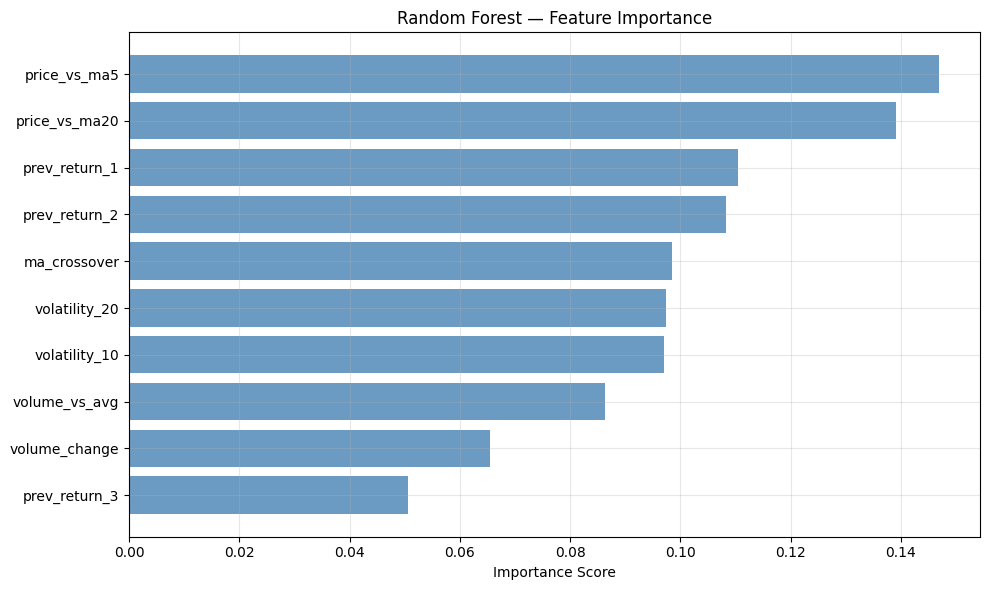


Top 5 most important features:
  price_vs_ma5         0.147
  price_vs_ma20        0.1391
  prev_return_1        0.1104
  prev_return_2        0.1083
  ma_crossover         0.0984


In [5]:
# Random Forest gives much richer feature importance
importance_rf = pd.DataFrame({
    'feature': features,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_rf['feature'], importance_rf['importance'], 
         color='steelblue', alpha=0.8)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
top5 = importance_rf.sort_values('importance', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['feature']:<20} {round(row['importance'], 4)}")

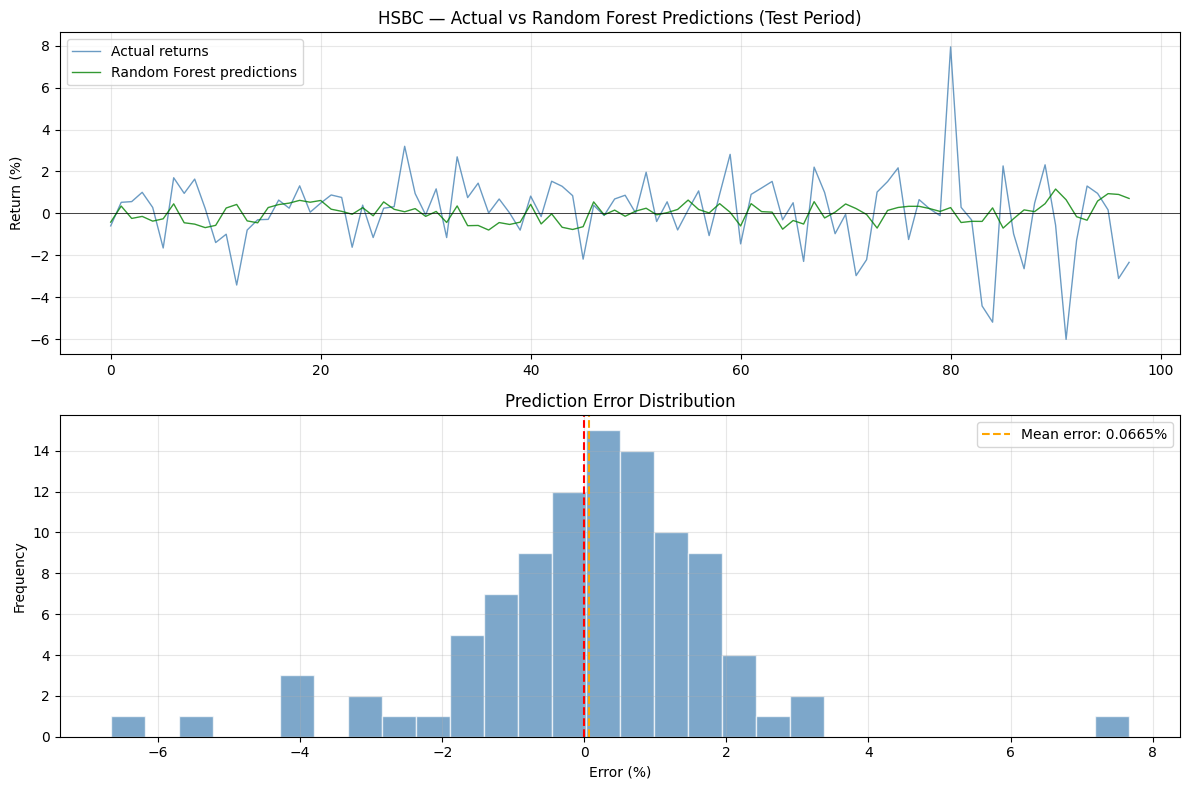

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1 — actual vs both model predictions
ax1.plot(y_test.values, label='Actual returns', 
         color='steelblue', linewidth=1, alpha=0.8)
ax1.plot(y_pred_rf, label='Random Forest predictions', 
         color='green', linewidth=1, alpha=0.8)
ax1.set_title('HSBC — Actual vs Random Forest Predictions (Test Period)')
ax1.set_ylabel('Return (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linewidth=0.5)

# Plot 2 — prediction error distribution
errors = y_test.values - y_pred_rf
ax2.hist(errors, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(x=0, color='red', linewidth=1.5, linestyle='--')
ax2.axvline(x=errors.mean(), color='orange', linewidth=1.5, 
            linestyle='--', label=f'Mean error: {round(errors.mean(), 4)}%')
ax2.set_title('Prediction Error Distribution')
ax2.set_xlabel('Error (%)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
print("=" * 55)
print("RANDOM FOREST vs LINEAR REGRESSION — SUMMARY")
print("=" * 55)
print(f"""
MODELS COMPARED
  Linear Regression — simple, assumes linearity
  Random Forest     — 500 trees, non-linear, ensemble

RESULTS ON SAME HSBC DATA (2 years, 13 features)
  Model                R²        RMSE
  Linear Regression   -0.0488    1.8332%
  Random Forest       {round(r2_rf, 4)}    {round(rmse_rf, 4)}%

KEY FINDINGS
  1. Neither model can reliably predict HSBC returns
     — confirms market efficiency for price-based features
     
  2. Random Forest underperformed Linear Regression
     — bias-variance tradeoff: complex models overfit
       noisy financial data
       
  3. Feature importance shifted between models
     — Linear model: volatility dominated
     — Random Forest: price vs MA dominated
     — same features, different perspectives on signal
     
  4. Error distribution centred at zero
     — no systematic bias in either direction
     — model errors are random, not directional

TOP RANDOM FOREST FEATURES
  1. price_vs_ma5    ({round(model_rf.feature_importances_[features.index('price_vs_ma5')], 4)}) — mean reversion signal
  2. price_vs_ma20   ({round(model_rf.feature_importances_[features.index('price_vs_ma20')], 4)}) — longer term mean reversion
  3. prev_return_1   ({round(model_rf.feature_importances_[features.index('prev_return_1')], 4)}) — short term momentum

CONCLUSION
  Predicting return magnitude is extremely hard.
  Next step: change the problem entirely.
  Instead of predicting HOW MUCH the stock moves,
  predict WHICH DIRECTION it moves — up or down.
  That is a classification problem, and it opens
  up a whole new set of more powerful algorithms.
""")
print("=" * 55)

RANDOM FOREST vs LINEAR REGRESSION — SUMMARY

MODELS COMPARED
  Linear Regression — simple, assumes linearity
  Random Forest     — 500 trees, non-linear, ensemble

RESULTS ON SAME HSBC DATA (2 years, 13 features)
  Model                R²        RMSE
  Linear Regression   -0.0488    1.8332%
  Random Forest       -0.0602    1.8431%

KEY FINDINGS
  1. Neither model can reliably predict HSBC returns
     — confirms market efficiency for price-based features

  2. Random Forest underperformed Linear Regression
     — bias-variance tradeoff: complex models overfit
       noisy financial data

  3. Feature importance shifted between models
     — Linear model: volatility dominated
     — Random Forest: price vs MA dominated
     — same features, different perspectives on signal

  4. Error distribution centred at zero
     — no systematic bias in either direction
     — model errors are random, not directional

TOP RANDOM FOREST FEATURES
  1. price_vs_ma5    (0.147) — mean reversion signal
